# 04 `fpos` Model Progression

This notebook is the main positive result of the thesis. It reconstructs the `fpos` path from weak transfer baselines to the final waveform-enhanced, trust-aware, family-balanced winner.

**Questions answered here**
- How much does each modeling wave improve over the simple transfer baseline?
- Which ablation blocks mattered most?
- Were the gains broad across recordings and families, or concentrated in a few easy regimes?


## Model Architecture Rebuild Spec (Code-Accurate)

### Shared Setup (All Recipes)

- **Dataset**: `data/raw/33000_ROWS.parquet` — ~33 000 spike-sorted units from SpikeForest
- **Split protocol**: `recording_disjoint_main` — train/val/test splits are recording-disjoint (no recording appears in more than one partition). `random_state=42`.
- **Paired adaptation pool**: units from paired (electrophysiology + ground-truth) recordings; labels available for all rows.
- **Unlabeled pool**: units from hybrid (SpikeForest synthetic) recordings; labels used only for source pre-training, not target fine-tuning.
- **Target transform**: logit (all models predict `logit(fpos)` or `logit(fmiss)`, inverse-transformed at evaluation).
- **Holdout size**: 100 paired rows withheld as the final holdout set (never seen during model selection).

---

### Recipe 1 — `fpos_dummy` — Sanity floor

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("dummy",))`

Predicts the mean of the **paired training labels** for every test unit. No features, no model. Pure floor. Used to confirm that any feature-based model at least beats the trivial mean prediction.

> Result key: `inductive|dummy|paired_mean|none`

---

### Recipe 2 — `fpos_paired_raw` — Paired-only raw baseline

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("paired_only",), feature_view_sets=(("unit_raw", ("unit_raw",)),))`

- **Training data**: Paired recordings only (no hybrid data used at all)
- **Features**: `unit_raw` — raw per-unit features: waveform statistics (peak, trough, width, asymmetry, repolarisation slope), firing rate, ISI metrics. No recording-level context.
- **Model**: LightGBM (250 trees, lr=0.05, num_leaves=31)

Shows the performance achievable with a small, label-pure dataset and no domain-awareness.

> Result key: `inductive|paired_only|lightgbm|unit_raw`

---

### Recipe 3 — `fpos_hybrid_only` — Pure source failure

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("hybrid_only",), feature_view_sets=(("unit_raw", ("unit_raw",)),))`

- **Training data**: Hybrid recordings only (large source pool, no paired labels)
- **Features**: `unit_raw`
- **Model**: XGBoost (250 trees, lr=0.05, max_depth=6)

Demonstrates that naive transfer without any domain correction severely underperforms. Domain shift is severe enough that a purely source-trained model is nearly useless on paired data.

> Result key: `inductive|hybrid_only|xgboost|unit_raw`

---

### Recipe 4 — `fpos_hybrid_calibrated` — Post-hoc calibration

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("hybrid_calibrated",), feature_view_sets=(("unit_raw", ("unit_raw",)),))`

- **Training data**: Hybrid for the XGBoost base model; paired for the isotonic calibration layer
- **Features**: `unit_raw`
- **Model**: XGBoost → isotonic regression calibration (monotone output recalibration fitted on paired adaptation rows)

Simple but principled post-hoc correction: the hybrid model’s output is passed through a non-parametric isotonic layer fitted on the paired labels. Tests whether the domain shift is purely a scaling/monotonicity issue.

> Result key: `inductive|hybrid_calibrated|xgboost+isotonic|unit_raw`

---

### ⭐ Recipe 5 — `fpos_hybrid_plus_paired` — Basic transfer baseline (reference line)

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("hybrid_plus_paired",), paired_weight_grid=(25.0,))`

- **Training data**: Hybrid + paired pooled together in a single XGBoost fit
- **Features**: `unit_raw`
- **Model**: XGBoost trained with paired rows upweighted **25×** relative to hybrid rows
  - Hyperparams: 250 trees, lr=0.05, max_depth=6

**This is the canonical baseline for the thesis.** All waterfall charts draw a dashed reference line here. The 25× weight was selected by grid search over (10, 25, 50) on CV. It gives paired labels substantially more influence without discarding the source data completely.

> Result key: `inductive|hybrid_plus_paired|xgboost_w25|unit_raw`

---

### Recipe 6 — `fpos_hybrid_residual` — First stacking attempt

**Implementation**: `LegacyTransferFamily` → `QCTransferBenchmark(model_families=("hybrid_stack",))`

- **Stage 1**: LightGBM on hybrid training data → source predictions
- **Stage 2**: LightGBM on paired data learning the **residual** of stage-1 predictions
- **Features**: `unit_raw` at both stages

First attempt at non-linear stacking. Tests whether a residual correction layer on top of the source model is more effective than pooling.

> Result key: `inductive|hybrid_stack|lightgbm_residual|unit_raw`

---

### Recipe 7 — `fpos_paired_context` — Context-only ablation

**Implementation**: `ContextStackFamily` → `run_context_stack`, variant `contextual_paired_only_lightgbm`

- **Training data**: Paired only (pseudo-labels disabled: `no_pseudo=True`)
- **Features**: Full context feature set — `norm_swap` (normalisation-swap augmented features), `recording_relative` (unit features expressed relative to recording-level statistics), `recording_context` (recording-level summary statistics), `study_identity` (one-hot study indicators). No `source_pred`, no anchor scores.
- **Model**: LightGBM (250 trees, lr=0.05, num_leaves=31), `family_alpha=1.0`

Ablation: measures the lift from context features alone, without any source supervision signal. Establishes that context features are load-bearing.

> Result key: `contextual_paired_only_lightgbm`

---

### Recipe 8 — `fpos_context_stack` — Context-first source stack (pre-neural baseline)

**Implementation**: `ContextStackFamily` → `run_context_stack`, variant `embed_nommd_fullctx_lightgbm`

- **Training data**: Paired (labeled) + cluster-trust pseudo-labeled hybrid rows
- **Features**: Full context set + `source_pred` (source XGBoost prediction on target domain) + `anchor_fp_score` (nearest-neighbor anchor similarity score) + `matched_support_conf` + `anchor_support_margin`
- **Domain reweighting**: Logistic regression domain classifier (C=1.0) computes importance weights; clipped to [0.2, 5.0]
- **Pseudo-labels**: Cluster-trust scheme:
  - KMeans subgroups (k ∈ {2, 3, 4}) fitted on context features
  - Trust score = cluster coverage × cluster_trust_power (1.35) × study_trust_weight (0.30)
  - Budget: max 48 pseudo/recording, max ratio 1.5× labeled rows, min trust 0.25
- **Model**: LightGBM (250 trees, lr=0.05, num_leaves=31), `family_alpha=1.0`

Best result before the anchor stack and waveform embeddings. This is the model that SSL/MMD are compared against in the neural detour section.

> Result key: `embed_nommd_fullctx_lightgbm`

---

### Recipe 9 — `fpos_ssl` — SSL neural pipeline (failed)

**Implementation**: `SSLFamily` → `run_ssl_with_config(SSLDomainAdaptationConfig)`

Full neural pipeline as the prediction model. Four sequential training stages:

1. **SSL pre-training** on the unlabeled hybrid pool: masked denoising autoencoder (mask_prob=0.15, noise_std=0.05), 20 epochs, lr=5e-3, AdamW, weight_decay=1e-4
2. **Source warmup** on hybrid labels: 3 epochs, lr=2e-3 × 0.75 (fpos-specific scale)
3. **Source supervised training**: 18 epochs, SmoothL1 loss
4. **Paired fine-tuning**: 12 epochs, lr=8e-4 × 0.75, patience=5

Architecture: encoder (hidden_dim=96, latent_dim=64) + contextual head (context_hidden_dim=48)\
Input features: `recording_relative` + `recording_context` (contextual feature blocks only)\
Validation: 3-fold CV on paired data (val_fraction=0.40)

**Why it failed**: ~40 paired-domain adaptation rows provide insufficient label pressure to steer the contextual fine-tuning away from the source domain. The SSL pre-training learns a reasonable representation, but fine-tuning on so few labels overfits or fails to move the encoder meaningfully.

> Result key: `ssl_fpos_contextual`

---

### Recipe 10 — `fpos_mmd` — MMD neural pipeline (failed)

**Implementation**: `MMDFamily` → `run_mmd_with_config(MMDDomainAdaptationConfig)`

Full neural pipeline with explicit domain distribution alignment via Maximum Mean Discrepancy:

1. **Source training with MMD penalty**: 25 epochs, lr=2e-3, AdamW, weight_decay=1e-4
   - MMD kernel: RBF multi-scale (bandwidth multipliers: 0.25, 0.5, 1.0, 2.0, 4.0)
   - Lambda (domain loss weight) selected by CV from grid (0.0, 0.01, 0.05, 0.1, 0.25)
2. **Paired fine-tuning**: 12 epochs, lr=8e-4, patience=5, SmoothL1 loss

Architecture: same encoder (hidden_dim=96, latent_dim=64). MMD loss penalises the distance between the hybrid and paired distributions in latent space during source training, so the encoder learns a domain-invariant representation before fine-tuning.

**Why it failed**: Same root cause as SSL — the paired fine-tuning stage has too few labels to exploit the aligned latent space. MMD alignment is effective in the source domain but the target task still requires paired supervision to move.

> Result key: `neural_mmd_finetuned`

---

### Recipe 11 — `fpos_pre_waveform_unlabeled` — Pseudo-label + anchor stack

**Implementation**: `AnchorStackFamily` → `run_anchor_stack`, variant `source_reweighted_anchor_stack_cluster_trust_pseudo_xgboost_default`

Extends the context stack with the full anchor mechanism:

- **Features**: Full context + `source_pred` + `anchor_fp_score` + `anchor_support_margin` (4-column anchor block)
- **Anchor scores**: Fitted via nearest-neighbour lookup in the paired adaptation pool; `anchor_fp_score` = distance-weighted mean of paired labels in the local neighbourhood
- **Pseudo-labels**: Same cluster-trust scheme as recipe 8 (max 48/recording, trust power 1.35)
- **Domain reweighting**: Importance weights from domain classifier, clipped to [0.2, 5.0]
- **Model**: **XGBoost** (350 trees, lr=0.04, max_depth=4, min_child_weight=4.0, subsample=0.8, colsample_bytree=0.8) — shallower than the source stage to reduce overfitting

**This is the strongest tabular result before waveform embeddings** and the direct predecessor of the winner.

> Result key: `source_reweighted_anchor_stack_cluster_trust_pseudo_xgboost_default`

---

### Recipe 12 — `fpos_family_balanced` — Family-balanced robustness variant

**Implementation**: `RobustnessStackFamily` → `run_robustness_stack`, variant `family_balanced_strong_xgboost` (family_alpha=1.0)

- **Same features as Recipe 11** (full anchor stack)
- **Modification**: XGBoost sample weights are re-computed so that each paired family (study_set) contributes **equally** to the loss, regardless of family size
  - family_alpha=1.0 = full balancing (uniform family weight)
  - family_alpha=0.0 = no balancing (reference)
  - family_alpha=0.5 = partial balancing (mild)
- **Model**: XGBoost (same hyperparams as Recipe 11)

Tests the robustness-vs-accuracy tradeoff. May sacrifice mean R² slightly in exchange for more consistent performance across rare or small paired families.

> Result key: `family_balanced_strong_xgboost`

---

### ⭐ Recipe 13 — `fpos_waveform_winner` — Final winner

**Implementation**: `WaveformStackFamily` → `run_waveform_stack`, variant `wf_embed_anchor_stack_xgboost`

Adds a **self-supervised convolutional autoencoder** as a feature extractor on top of the anchor stack. This is the only recipe in the fpos ladder with a neural component.

#### Neural component: `SignalConvAutoencoder`

Architecture (encoder path):
```
Input waveform: [N, 1, input_len]  (standardised, imputed)
  → Conv1d(1 → 12 ch, kernel=3, padding=1) → ReLU
  → Conv1d(12 → 12 ch, kernel=3, padding=1) → ReLU
  → Flatten → Linear(12 × input_len → 8)
  = 8-dim embedding
```
Decoder mirrors encoder (Linear → Unflatten → Conv1d × 2) with SmoothL1 reconstruction loss.

Training procedure:
- **Training universe**: up to 18 000 rows sampled from the full dataset (train + unlabeled pool combined), scaled with `StandardScaler` + `SimpleImputer(median)`
- **Optimiser**: AdamW, lr=2e-3, weight_decay=1e-4
- **Epochs**: 28, batch_size=256
- **No labels required**: reconstruction objective only — self-supervised
- **Output columns**: `wf_embed_00` … `wf_embed_07` (8 columns)

#### Stack construction

1. Build the full anchor stack (identical to Recipe 11 features)
2. Train the conv-AE on the combined universe
3. Encode train, unlabeled, and test rows through the frozen encoder
4. **Concatenate** the 8 waveform embedding columns onto the anchor stack features
5. Train XGBoost (350 trees, lr=0.04, max_depth=4, min_child_weight=4.0, subsample=0.8, colsample_bytree=0.8) on the augmented feature matrix

#### Why it works

The conv-AE learns spike shape variation from the entire unlabeled pool without needing any labels. The 8-dim embedding captures modes that correlate with false-positive rate (spike width, peak-trough asymmetry, repolarisation slope) in a compressed, noise-robust form that raw waveform columns do not provide cleanly. Label pressure is not required at the embedding stage — only at the final XGBoost layer. This is the key architectural insight: **neural as feature extractor, not as prediction pipeline**.

> Result key: `wf_embed_anchor_stack_xgboost`

---

### Summary

| recipe_id | Stage | Approach | Key addition vs. predecessor |
|---|---|---|---|
| fpos_dummy | baseline | dummy floor | — |
| fpos_hybrid_only | baseline | pure source | source data only |
| fpos_hybrid_calibrated | baseline | source + calibration | isotonic post-hoc correction |
| **fpos_hybrid_plus_paired** | **baseline** | **basic transfer (reference)** | **25× paired upweighting** |
| fpos_hybrid_residual | baseline | residual stack | paired residual layer |
| fpos_paired_context | main text | pure tabular | context features (no source signal) |
| fpos_context_stack | main text | pure tabular | source_pred + anchor scores + pseudo-labels |
| fpos_ssl | main text | neural pipeline | SSL masked-AE pre-training (failed) |
| fpos_mmd | main text | neural pipeline | MMD latent alignment (failed) |
| fpos_pre_waveform_unlabeled | main text | pure tabular | full anchor stack + XGBoost |
| fpos_family_balanced | main text | pure tabular | family-balanced sample weights |
| **fpos_waveform_winner** | **main text** | **tabular + SSL features** | **+8 conv-AE waveform embeddings** |


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve().parent
SRC = ROOT / "src"
if not SRC.exists():
    raise FileNotFoundError(f"Expected thesis src at {SRC}; run notebooks from thesis/notebooks")
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("04_fpos_model_progression")
benchmark = build_benchmark_progress_table("fpos")
ablation_winners = build_ablation_winner_table("fpos")
wave_ids = ["fpos_paired_context", "fpos_context_stack", "fpos_pre_waveform_unlabeled", "fpos_family_balanced", "fpos_waveform_winner"]
waves = build_main_wave_summary("fpos", wave_ids)
winner_diag = build_prediction_diagnostics("fpos_waveform_winner", "fpos")
limitations = get_limitations_bundle()


## 0. Recipe system: running the experiments

The thesis uses a recipe-based experiment system. Each `RecipeSpec` encodes a complete modeling hypothesis: target, feature view, model family, ablation group, and result key. `load_or_run_experiment` checks for cached artifacts first and runs the recipe live only when needed.

The full `fpos` research path below has seven stages. Stages 3 and 4 (SSL, MMD) are the necessary detour that ruled out neural domain adaptation before the tabular stacking breakthrough.

In [2]:
PROTOCOL = "recording_disjoint_main"

# Load or run every key milestone — cached on disk, runs live if missing
result_dummy       = load_or_run_experiment("fpos_dummy",                "fpos", PROTOCOL)
result_basic       = load_or_run_experiment("fpos_hybrid_plus_paired",   "fpos", PROTOCOL)
result_ssl         = load_or_run_experiment("fpos_ssl",                  "fpos", PROTOCOL)
result_mmd         = load_or_run_experiment("fpos_mmd",                  "fpos", PROTOCOL)
result_context     = load_or_run_experiment("fpos_context_stack",        "fpos", PROTOCOL)
result_unlabeled   = load_or_run_experiment("fpos_pre_waveform_unlabeled","fpos", PROTOCOL)
result_winner      = load_or_run_experiment("fpos_waveform_winner",      "fpos", PROTOCOL)

def _m(result):
    row = result.metrics.iloc[0] if not result.metrics.empty else {}
    return {"r2": float(row.get("r2", float("nan"))), "mae": float(row.get("mae", float("nan")))}

milestones = pd.DataFrame([
    {"stage": "1  sanity floor",         "model": result_dummy.recipe.label,     **_m(result_dummy)},
    {"stage": "2  basic transfer",        "model": result_basic.recipe.label,     **_m(result_basic)},
    {"stage": "3  neural SSL",            "model": result_ssl.recipe.label,       **_m(result_ssl)},
    {"stage": "4  neural MMD",            "model": result_mmd.recipe.label,       **_m(result_mmd)},
    {"stage": "5  context stacking",      "model": result_context.recipe.label,   **_m(result_context)},
    {"stage": "6  + unlabeled paired",    "model": result_unlabeled.recipe.label, **_m(result_unlabeled)},
    {"stage": "7  + waveform embedding",  "model": result_winner.recipe.label,    **_m(result_winner)},
])
display(milestones)
save_table(milestones, table_dir, "fpos_milestone_trajectory")

,stage,model,r2,mae
0,1 sanity floor,Dummy paired mean,-0.000221,0.191016
1,2 basic transfer,Hybrid+paired basic XGBoost,0.270975,0.148397
2,3 neural SSL,Best SSL neural,-1.057136,0.276944
3,4 neural MMD,Best MMD neural,0.304869,0.150319
4,5 context stacking,Context-first source stack,0.521520,0.118961
5,6 + unlabeled paired,Pre-waveform unlabeled structure,0.501473,0.117866
6,7 + waveform embedding,Waveform winner,0.533189,0.116062


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_milestone_trajectory.csv')

## 1. Benchmark ladder

The right baseline for the thesis is not the dummy model; it is the **basic hybrid+paired XGBoost transfer baseline**. Everything after that should be interpreted as an incremental answer to a specific scientific problem.


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer
0,Dummy paired mean,0.1910,0.2465,-0.0002,-0.0037,0.0000,-0.2712
0,Paired-only raw,0.1236,0.1743,0.4996,-0.0357,0.9638,0.2286
0,Hybrid-only XGBoost,0.2515,0.3419,-0.9251,0.1789,0.3919,-1.1961
0,Calibrated hybrid XGBoost,0.1573,0.2223,0.1865,-0.0183,1.0757,-0.0845
0,Hybrid+paired basic XGBoost,0.1484,0.2104,0.2710,0.0794,0.6655,0.0000
0,Hybrid stack residual,0.1471,0.1931,0.3860,0.0316,0.7680,0.1150
0,Paired-only context,0.1328,0.1798,0.4675,-0.0337,1.0265,0.1965
0,Context-first source stack,0.1190,0.1705,0.5215,-0.0374,1.2119,0.2505
0,Best SSL neural,0.2769,0.3534,-1.0571,0.1944,0.3655,-1.3281
0,Best MMD neural,0.1503,0.2055,0.3049,0.0276,0.7123,0.0339


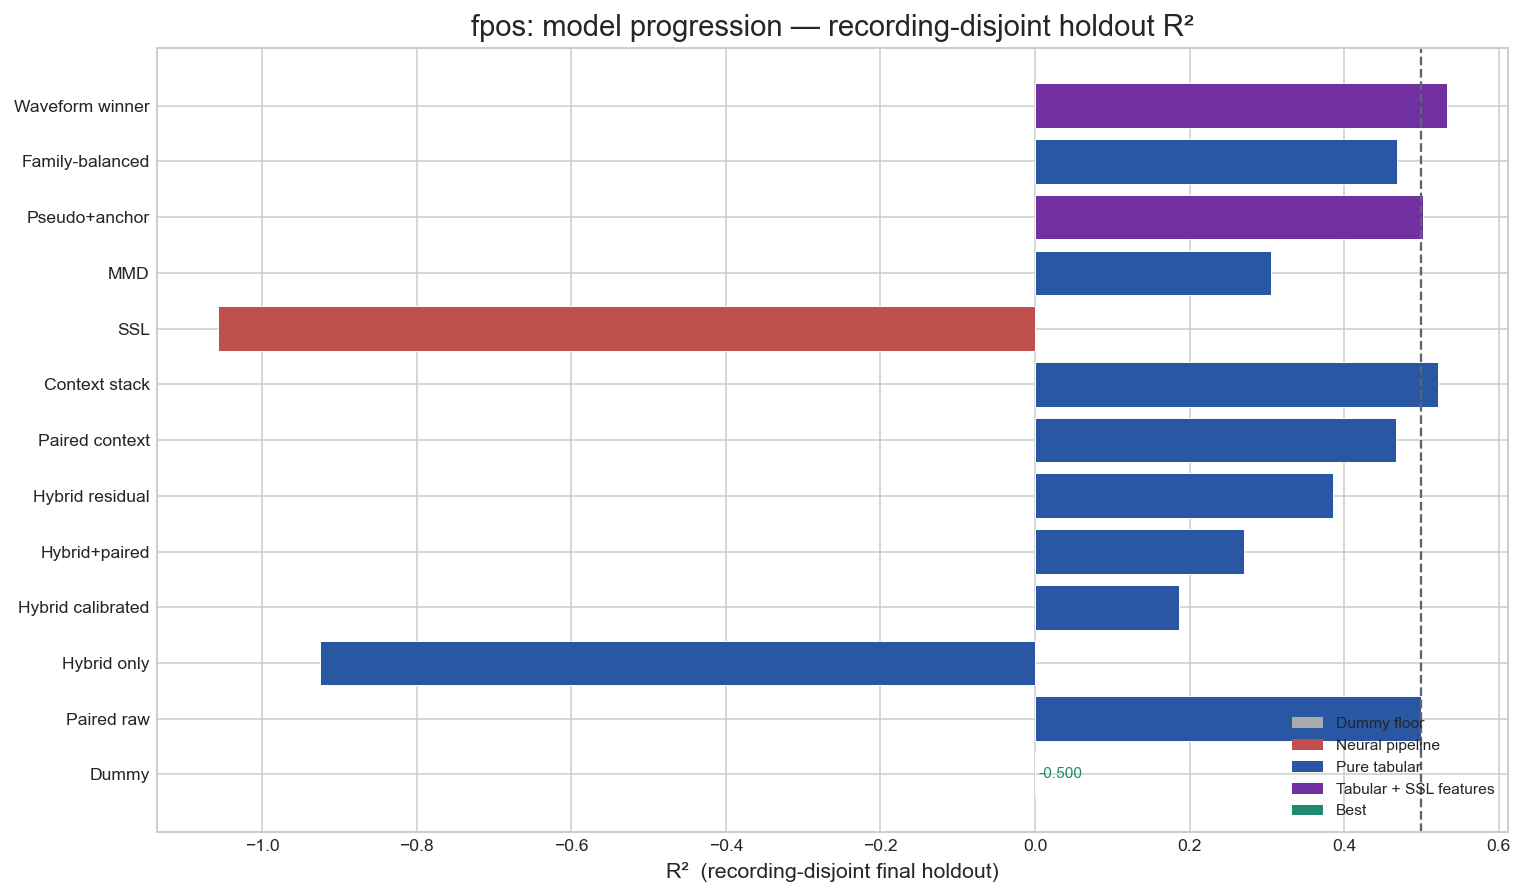

In [3]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer"]].round(4))
save_table(benchmark, table_dir, "fpos_benchmark_ladder")

# Evaluated on the recording-disjoint final holdout (100 paired rows, never seen during selection)
fig, _ = plot_waterfall_progression(benchmark, metric="r2",
                                     title="fpos: model progression — recording-disjoint holdout R²")
save_figure(fig, fig_dir, "fpos_benchmark_r2")
display(fig)
plt.close(fig)


,label,r2,delta_r2,ci_95,p_value,stars
0,Dummy paired mean,-0.0002,0.0,—,NaN,baseline
1,Hybrid+paired basic XGBoost,0.2710,0.0,—,NaN,baseline
2,Best SSL neural,-1.0571,0.0,—,NaN,baseline
3,Best MMD neural,0.3049,0.0,—,NaN,baseline
4,Context-first source stack,0.5215,0.0,—,NaN,baseline
5,Pre-waveform unlabeled structure,0.5015,0.0,—,NaN,baseline
6,Waveform winner,0.5332,0.0,—,NaN,baseline


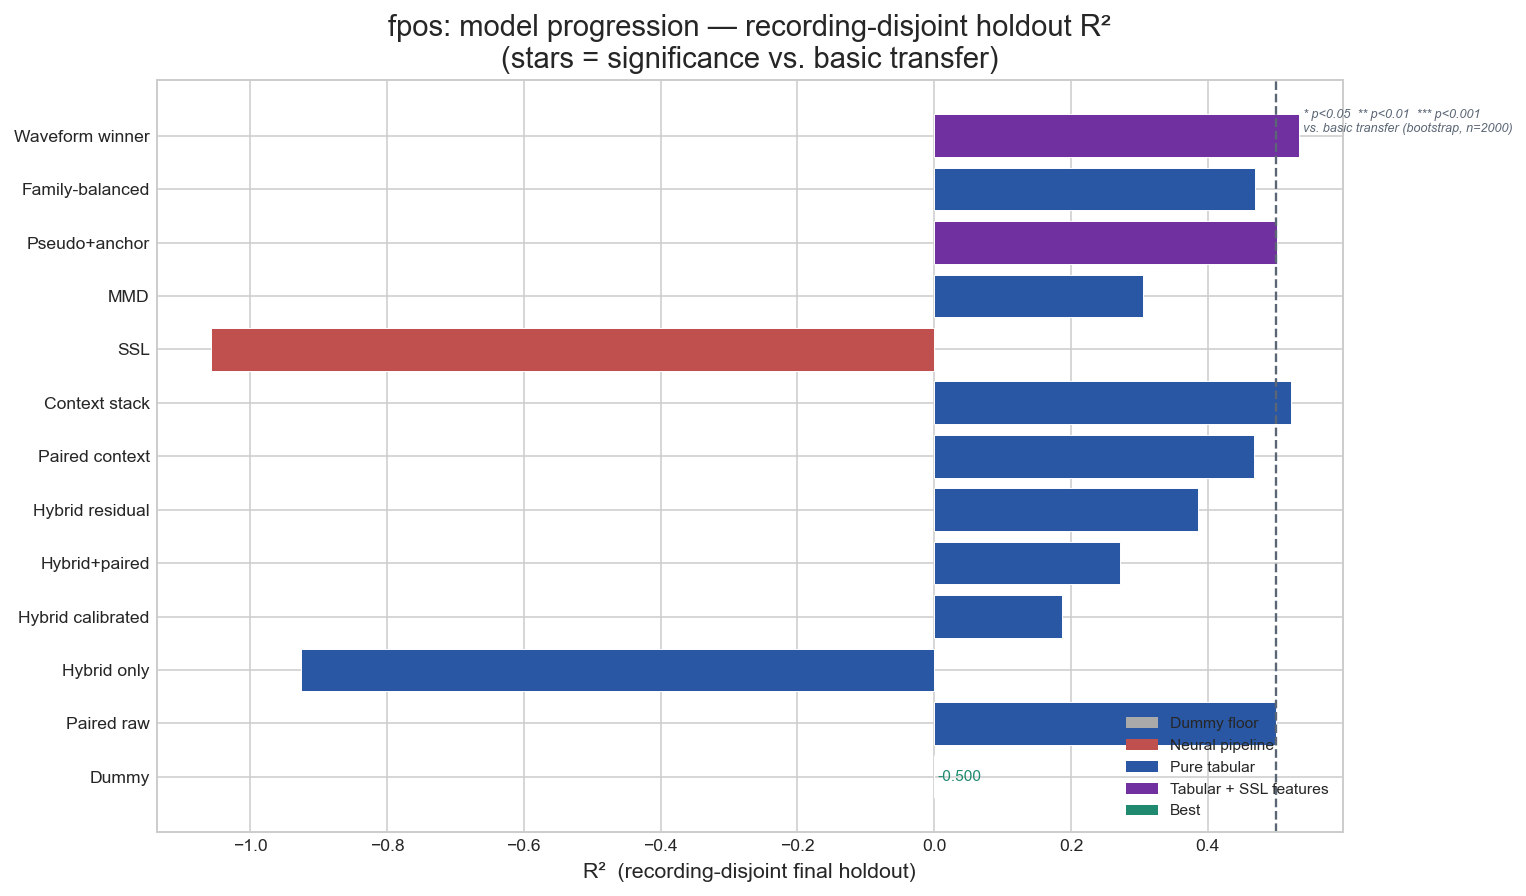

In [4]:
# ── Bootstrap significance vs. basic transfer baseline ──────────────────────
# H₀: ΔR²(model − basic transfer) ≤ 0
# Method: non-parametric bootstrap (n=2000 resamples of the 100-row holdout set)
# p-value = fraction of bootstrap samples where ΔR² ≤ 0 (one-sided; model is better)
# Significance: * p<0.05  ** p<0.01  *** p<0.001  n.s. = not significant
PROTOCOL = "recording_disjoint_main"

_milestone_results = [
    ("fpos_dummy",                 result_dummy),
    ("fpos_hybrid_plus_paired",    result_basic),
    ("fpos_ssl",                   result_ssl),
    ("fpos_mmd",                   result_mmd),
    ("fpos_context_stack",         result_context),
    ("fpos_pre_waveform_unlabeled",result_unlabeled),
    ("fpos_waveform_winner",       result_winner),
]

# Collect holdout predictions for each recipe (aligning on test unit index)
_pred_frames = {}
for rid, res in _milestone_results:
    if res.predictions is not None and not res.predictions.empty:
        p = res.predictions[["true", "pred"]].copy()
        p["true"] = pd.to_numeric(p["true"], errors="coerce")
        p["pred"] = pd.to_numeric(p["pred"], errors="coerce")
        _pred_frames[rid] = p.reset_index(drop=True)

_baseline_key = "fpos_hybrid_plus_paired"
_b = _pred_frames.get(_baseline_key)

_sig_rows = []
for rid, res in _milestone_results:
    label = res.recipe.label
    pf = _pred_frames.get(rid)
    r2_val = float(res.metrics.iloc[0].get("r2", float("nan"))) if not res.metrics.empty else float("nan")

    if rid == _baseline_key or _b is None or pf is None:
        _sig_rows.append({"label": label, "r2": r2_val, "delta_r2": 0.0,
                          "ci_low": float("nan"), "ci_high": float("nan"),
                          "p_value": float("nan"), "stars": "baseline"})
        continue

    # Align lengths — both sets must come from the same holdout rows
    n = min(len(pf), len(_b))
    stats = bootstrap_r2_significance(
        _b["true"].iloc[:n], pf["pred"].iloc[:n], _b["pred"].iloc[:n],
        n_bootstrap=2000, seed=42
    )
    _sig_rows.append({"label": label, "r2": r2_val, **stats})

sig_table = pd.DataFrame(_sig_rows)
sig_table["ci_95"] = sig_table.apply(
    lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]" if r.ci_low == r.ci_low else "—", axis=1
)
display(sig_table[["label", "r2", "delta_r2", "ci_95", "p_value", "stars"]].round(4))
save_table(sig_table, table_dir, "fpos_significance_vs_basic_transfer")

# Build stars dict keyed by full label (waterfall checks both full and short)
_stars_map = {r["label"]: r["stars"] for r in _sig_rows}

# Re-plot waterfall with significance annotations
fig, _ = plot_waterfall_progression(
    benchmark, metric="r2",
    title="fpos: model progression — recording-disjoint holdout R²\n(stars = significance vs. basic transfer)",
    sig_stars=_stars_map,
)
save_figure(fig, fig_dir, "fpos_benchmark_r2_annotated")
display(fig)
plt.close(fig)


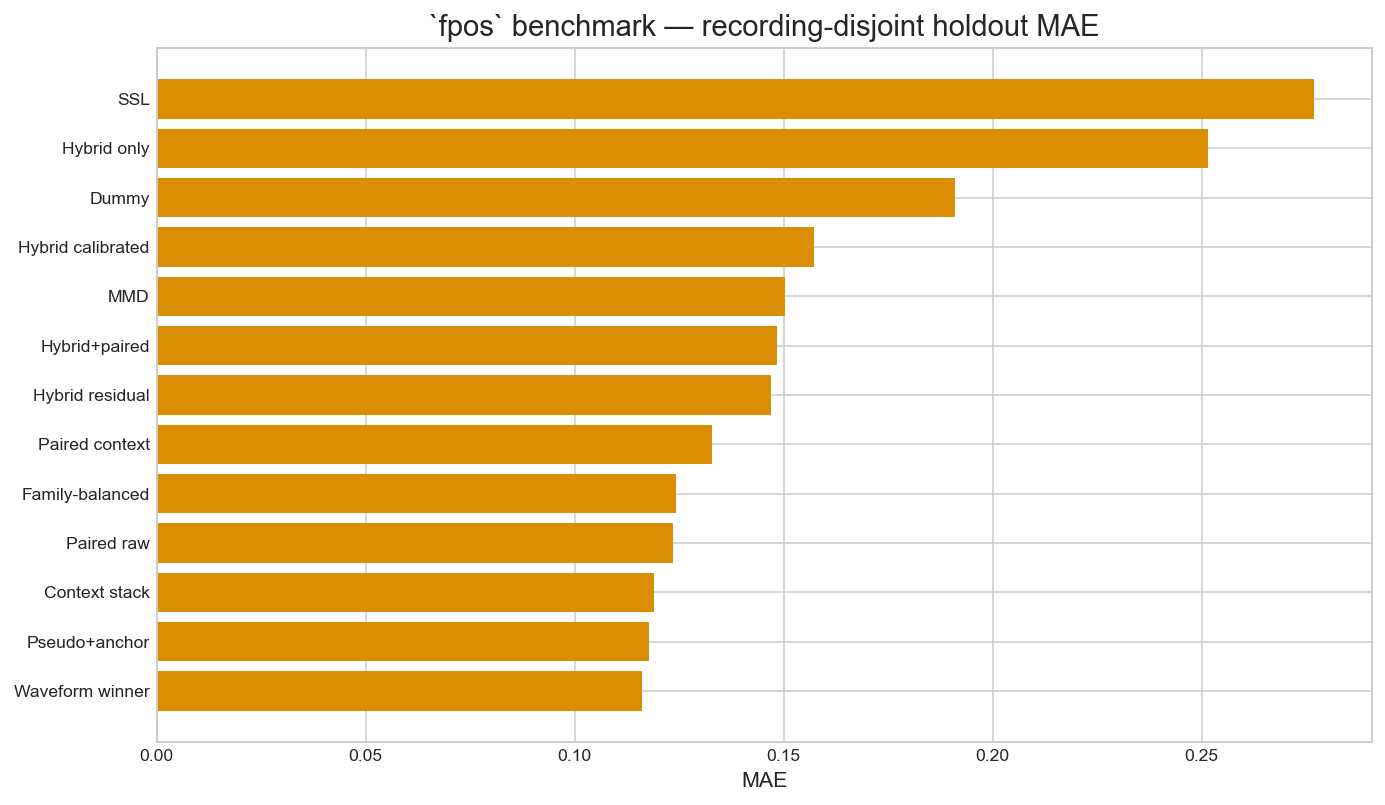

In [5]:
# Evaluated on the recording-disjoint final holdout (same split as R² chart above)
fig, _ = plot_benchmark_metric(benchmark, metric="mae",
                                title="`fpos` benchmark — recording-disjoint holdout MAE")
save_figure(fig, fig_dir, "fpos_benchmark_mae")
display(fig)
plt.close(fig)


In [6]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
simple_row = benchmark.loc[benchmark["recipe_id"] == "fpos_hybrid_plus_paired"].iloc[0]
display(Markdown(
    f"""
## Main progression result

- The simple hybrid+paired baseline reaches **R² {simple_row['r2']:.4f}**.
- The final waveform winner reaches **R² {winner_row['r2']:.4f}**.
- That is a gain of **{winner_row['r2'] - simple_row['r2']:+.4f} R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.
"""
))



## Main progression result

- The simple hybrid+paired baseline reaches **R² 0.2710**.
- The final waveform winner reaches **R² 0.5332**.
- That is a gain of **+0.2622 R²** over the basic transfer recipe.
- The thesis should therefore present `fpos` as a sequence of answers: context, unlabeled target structure, robustness weighting, and waveform representation.


### A necessary detour: neural domain adaptation

Before the context-first tabular stacking path became clear, two neural domain-adaptation recipes were explored: **SSL** (self-supervised contextual fine-tuning) and **MMD** (maximum mean discrepancy alignment). Both used the full neural pipeline as the prediction model — encoder + adaptation layers + regression head.

Both failed: R² improvement over the basic transfer baseline was negligible. The bottleneck was architectural: with only ~40 paired-domain adaptation rows, there was insufficient label pressure to steer the contextual fine-tuning away from the source domain.

**Important correction to the “neural failed” framing:** SSL and MMD failed when used as the *complete prediction pipeline*. The final winner (`fpos_waveform_winner`) eventually re-introduced neural signal — but only as a **self-supervised waveform feature extractor** (8-dim conv-AE embeddings), not as the predictor. Neural is not absent from the winner; it just plays a different role. The failure was not “neural vs tabular” — it was “neural pipeline vs tabular + neural features”.


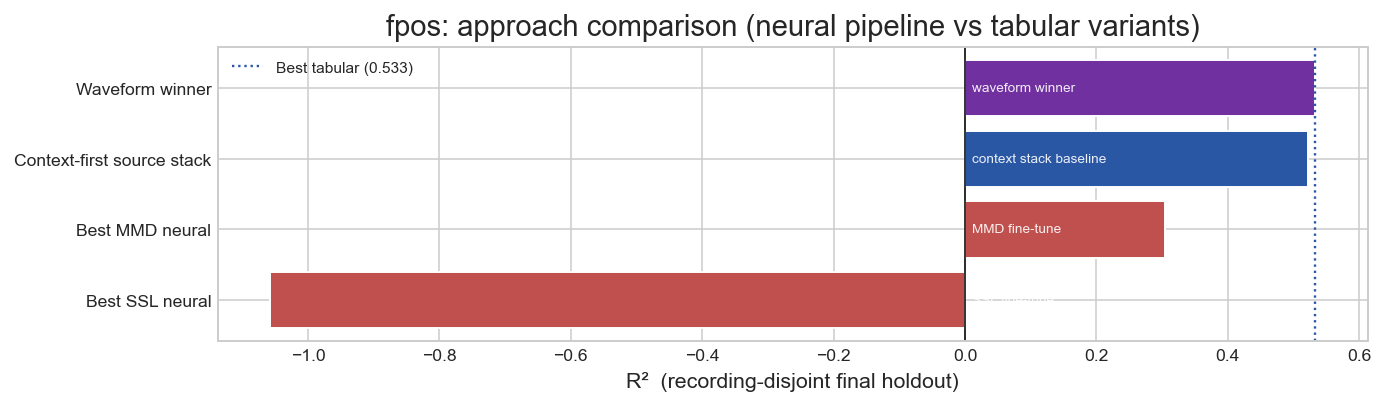

In [7]:
# Direct numeric comparison: neural attempts vs tabular context baseline
def _m(r):
    row = r.metrics.iloc[0] if not r.metrics.empty else {}
    return float(row.get("r2", float("nan")))

neural_compare = pd.DataFrame([
    {"model": result_ssl.recipe.label,     "approach_type": "neural pipeline",        "r2": _m(result_ssl),     "notes": "SSL fine-tune"},
    {"model": result_mmd.recipe.label,     "approach_type": "neural pipeline",        "r2": _m(result_mmd),     "notes": "MMD fine-tune"},
    {"model": result_context.recipe.label, "approach_type": "tabular",                "r2": _m(result_context), "notes": "context stack baseline"},
    {"model": result_winner.recipe.label,  "approach_type": "tabular + SSL features", "r2": _m(result_winner),  "notes": "waveform winner"},
])
save_table(neural_compare, table_dir, "fpos_neural_vs_tabular_comparison")

fig, _ = plot_approach_comparison(neural_compare,
                                   title="fpos: approach comparison (neural pipeline vs tabular variants)")
save_figure(fig, fig_dir, "fpos_approach_comparison")
display(fig)
plt.close(fig)


## 2. Which ablation blocks mattered?

Each ablation group corresponds to one scientific question. The goal is not to show every run equally, but to make the causal story of the winner understandable.


In [8]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fpos_ablation_winners")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_supervision,Paired-only raw,fpos_paired_raw,0.499605,0.123640,Small paired baseline
1,context,Context-first source stack,fpos_context_stack,0.521520,0.118961,Best pre-unlabeled context-first stack
2,unlabeled_paired_structure,Context-first source stack,fpos_context_stack,0.521520,0.118961,Best pre-unlabeled context-first stack
3,waveform_representation,Waveform winner,fpos_waveform_winner,0.533189,0.116062,Final fpos winner
4,robustness,Waveform winner,fpos_waveform_winner,0.533189,0.116062,Final fpos winner


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_ablation_winners.csv')

In [9]:
for group_name in ["source_supervision", "context", "unlabeled_paired_structure", "waveform_representation", "robustness"]:
    bundle = build_ablation_bundle("fpos", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fpos_ablation_{group_name}")


### Source Supervision

,label,mae,r2,notes
0,Dummy paired mean,0.191016,-0.000221,Sanity floor
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Hybrid-only XGBoost,0.251464,-0.925127,Pure source failure baseline
0,Calibrated hybrid XGBoost,0.157333,0.186473,Simple calibrated transfer
0,Hybrid+paired basic XGBoost,0.148397,0.270975,Basic transfer baseline
0,Hybrid stack residual,0.147101,0.385967,First nonlinear stack


### Context

,label,mae,r2,notes
0,Paired-only raw,0.123640,0.499605,Small paired baseline
0,Paired-only context,0.132842,0.467458,Context-only target baseline
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack


### Unlabeled Paired Structure

,label,mae,r2,notes
0,Context-first source stack,0.118961,0.521520,Best pre-unlabeled context-first stack
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant


### Waveform Representation

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant
0,Waveform winner,0.116062,0.533189,Final fpos winner


### Robustness

,label,mae,r2,notes
0,Pre-waveform unlabeled structure,0.117866,0.501473,Strongest positive result before waveform embe...
0,Family-balanced robustness,0.124264,0.468913,Robustness tradeoff variant
0,Waveform winner,0.116062,0.533189,Final fpos winner


## 3. Family and recording behavior of the main waves

The thesis should not claim improvement unless it can show that gains are broad. These summaries make it clear whether a new wave improved many recordings or only a handful.


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN,21,0.088048,0.121570,-0.863455,0.021138
1,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1,9,0.159556,0.208522,0.485703,-0.045567
2,fpos_paired_context,Paired-only context,PAIRED_ENGLISH,44,0.180991,0.225780,0.405088,-0.039343
3,fpos_paired_context,Paired-only context,PAIRED_KAMPFF,6,0.125307,0.144412,0.583394,-0.125307
4,fpos_paired_context,Paired-only context,PAIRED_MEA64C_YGER,20,0.064190,0.090593,0.385658,-0.045870
5,fpos_context_stack,Context-first source stack,PAIRED_BOYDEN,21,0.039797,0.052860,0.647694,0.000703
6,fpos_context_stack,Context-first source stack,PAIRED_CRCNS_HC1,9,0.141149,0.210923,0.473791,-0.083238
7,fpos_context_stack,Context-first source stack,PAIRED_ENGLISH,44,0.185454,0.226628,0.400612,-0.040691
8,fpos_context_stack,Context-first source stack,PAIRED_KAMPFF,6,0.107709,0.130946,0.657469,-0.102544
9,fpos_context_stack,Context-first source stack,PAIRED_MEA64C_YGER,20,0.049187,0.064745,0.686219,-0.030075


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias
0,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10,0.121279,0.160870,-3.176908,0.101827
1,fpos_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11,0.057838,0.068472,-0.050129,-0.052215
2,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1,0.321540,0.321540,NaN,-0.321540
3,fpos_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8,0.139308,0.189718,-0.032248,-0.011071
4,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3,0.307830,0.315963,-5.015567,-0.307830
5,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7,0.142988,0.153025,-1.419613,0.142988
6,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3,0.027625,0.032501,0.835701,0.025347
7,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6,0.266153,0.296268,0.032908,-0.091546
8,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6,0.125938,0.186152,0.643359,-0.012124
9,fpos_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3,0.155864,0.182182,-0.166735,-0.155864


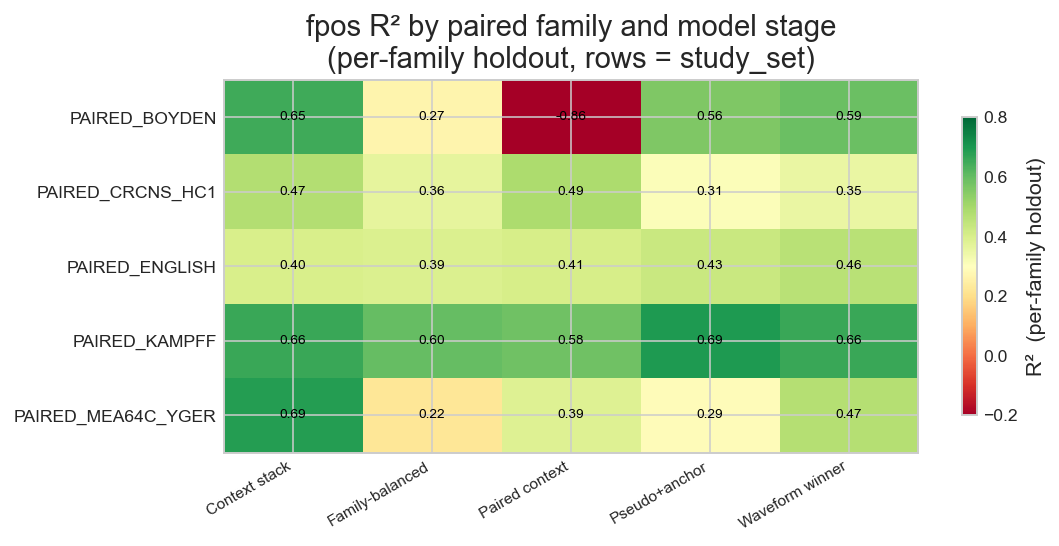

PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/tables/04_fpos_model_progression/fpos_family_r2_pivot.csv')

In [10]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fpos_family_wave_summary")
save_table(waves["recording"], table_dir, "fpos_recording_wave_summary")

# R² computed per paired family (study_set) on the holdout split.
# Each cell = mean R² across all units in that family × model combination.
fig, _, pivot = plot_family_r2_heatmap(
    waves["family"],
    title="fpos R² by paired family and model stage\n(per-family holdout, rows = study_set)"
)
save_figure(fig, fig_dir, "fpos_family_r2_by_wave")
display(fig)
plt.close(fig)
save_table(pivot, table_dir, "fpos_family_r2_pivot")


,label,recording_key,r2
0,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.746651
1,Waveform winner,PAIRED_KAMPFF::paired_kampff::c14,0.657032
2,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.495859
3,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,0.491276
4,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.253259
5,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.253114
6,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.107102
7,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.072563
8,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.070563
9,Waveform winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-0.389054


,label,recording_key,r2
0,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_19...,-3.149280
1,Waveform winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-1.120369
2,Waveform winner,PAIRED_ENGLISH::paired_english::m139_200114_22...,-1.075727
3,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,-0.587313
4,Waveform winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-0.389054
5,Waveform winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,0.070563
6,Waveform winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.072563
7,Waveform winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.107102
8,Waveform winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.253114
9,Waveform winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,0.253259


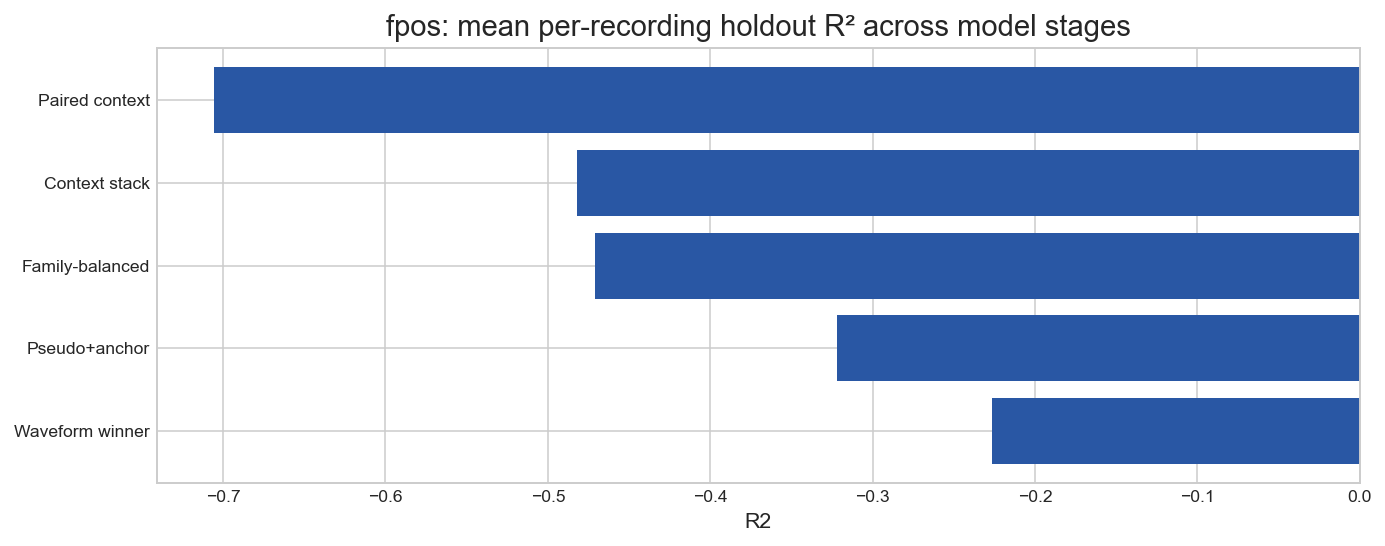

In [11]:
# Per-recording R²: each row = one recording in the holdout split.
# This is a finer-grained view than the family heatmap; recordings within the same family can diverge.
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(
    recording_mean[recording_mean["label"] == "Waveform winner"],
    group_col="recording_key", metric="r2", top_n=12
)
display(top_rec)
display(bottom_rec)
save_table(top_rec,    table_dir, "fpos_top_recordings")
save_table(bottom_rec, table_dir, "fpos_worst_recordings")

fig, _ = plot_benchmark_metric(
    waves["recording"].groupby("label", as_index=False)["r2"].mean().rename(columns={"r2":"r2","label":"label"}),
    metric="r2",
    title="fpos: mean per-recording holdout R² across model stages"
)
save_figure(fig, fig_dir, "fpos_top_recording_r2_by_wave")
display(fig)
plt.close(fig)


## 4. Diagnostics for the final winner

The final model is not only a score. We also want a structural read: does it track the target at all, and what robustness cost does it pay under family-unseen transfer?


,protocol,target,variant_id,family,backend,row_uid,recording_key,study_set,true,pred,abs_error,recipe_id,label,residual
0,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Iro...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.113636,0.152797,0.039161,fpos_waveform_winner,Waveform winner,0.039161
1,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::JRC...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261381,0.284694,0.023313,fpos_waveform_winner,Waveform winner,0.023313
2,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.112410,0.169673,0.057263,fpos_waveform_winner,Waveform winner,0.057263
3,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.170663,0.196328,0.025665,fpos_waveform_winner,Waveform winner,0.025665
4,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.333333,0.207217,0.126116,fpos_waveform_winner,Waveform winner,-0.126116
5,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Kil...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.158784,0.099575,0.059209,fpos_waveform_winner,Waveform winner,-0.059209
6,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Klu...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.156687,0.203055,0.046368,fpos_waveform_winner,Waveform winner,0.046368
7,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Mou...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.305322,0.312948,0.007626,fpos_waveform_winner,Waveform winner,0.007626
8,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Spy...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.122581,0.176133,0.053552,fpos_waveform_winner,Waveform winner,0.053552
9,main,fpos,wf_embed_anchor_stack_xgboost,signal_embedding_stack,xgboost_default,PAIRED_BOYDEN::paired_boyden32c::1103_1_1::Tri...,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,PAIRED_BOYDEN,0.261327,0.288410,0.027083,fpos_waveform_winner,Waveform winner,0.027083


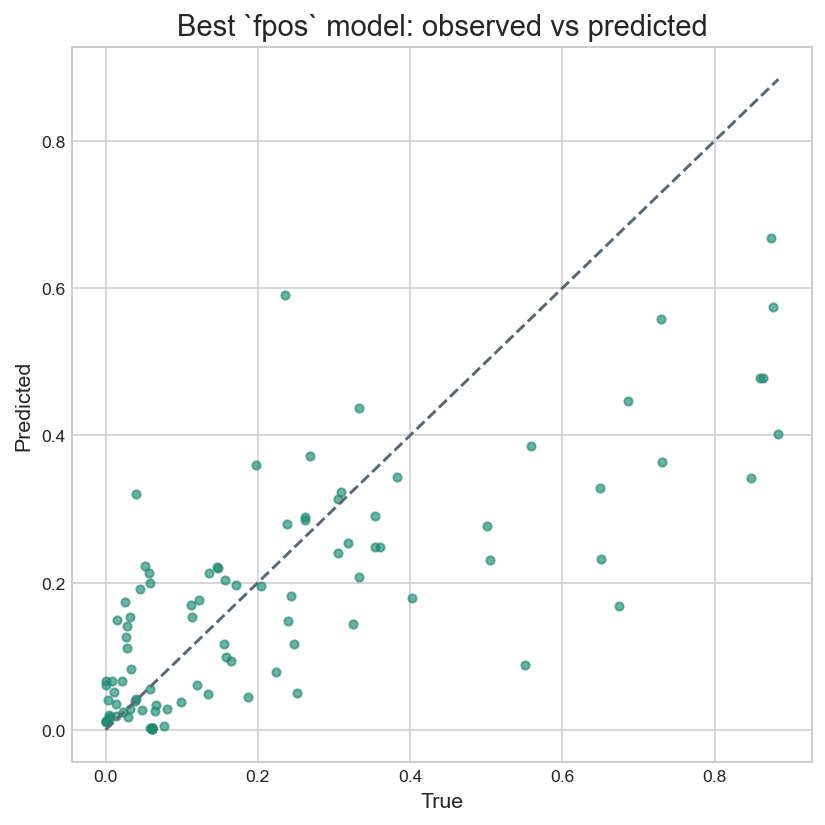

In [12]:
winner_predictions = winner_diag["predictions"]
display(winner_predictions.head(20))
fig, _ = plot_prediction_scatter(winner_predictions, title="Best `fpos` model: observed vs predicted")
save_figure(fig, fig_dir, "fpos_winner_prediction_scatter")
display(fig)
plt.close(fig)


,variant_id,macro_mae,macro_r2,weighted_mae,weighted_r2,worst_family_r2,best_family_r2
0,reference_anchor_stack_xgboost,0.125455,0.452724,0.131071,0.423981,0.293988,0.546858
1,wf_embed_anchor_stack_xgboost,0.122189,0.438568,0.126716,0.411617,0.148179,0.695184


,model,protocol,r2,mae,delta_r2_vs_recording,delta_mae_vs_recording
0,Waveform winner,recording_disjoint_main,0.533189,0.116062,0.000000,0.000000
1,Waveform winner,family_disjoint_lofo,0.438568,0.122189,-0.094622,0.006128


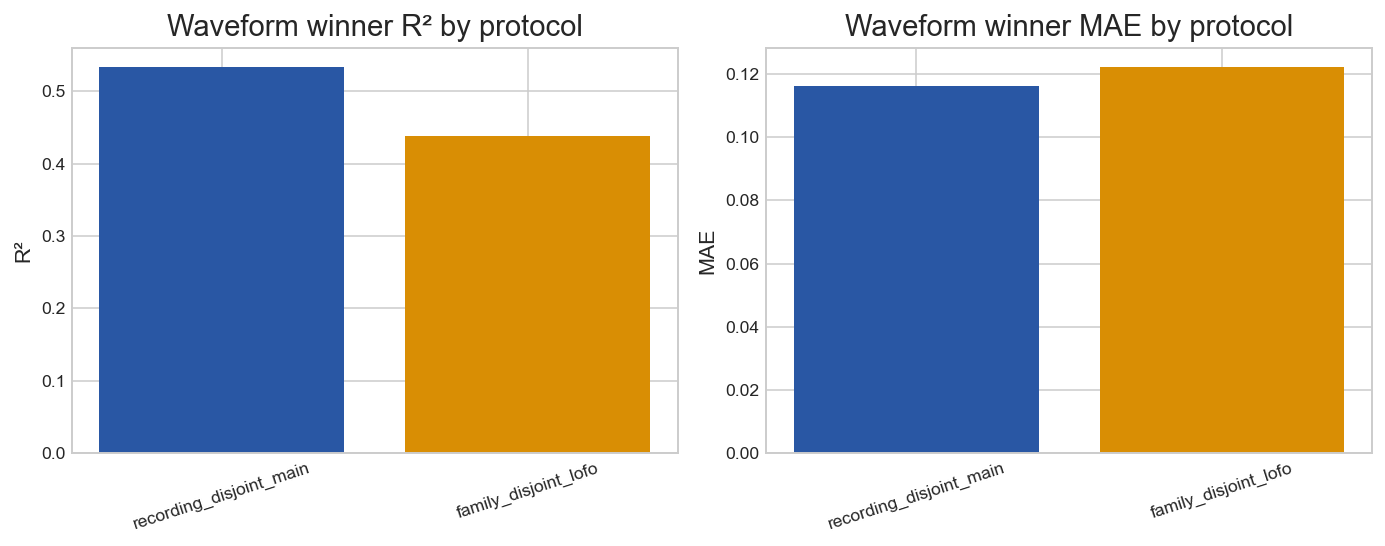

In [13]:
lofo_companion = limitations.lofo_aggregate[limitations.lofo_aggregate["variant_id"].isin(["reference_anchor_stack_xgboost", "family_balanced_strong_xgboost", "wf_embed_anchor_stack_xgboost"])].copy()
display(lofo_companion)
save_table(lofo_companion, table_dir, "fpos_family_held_out_companion")

winner_variant = "wf_embed_anchor_stack_xgboost"
winner_recording_r2 = float(result_winner.metrics.iloc[0]["r2"])
winner_recording_mae = float(result_winner.metrics.iloc[0]["mae"])
winner_lofo = limitations.lofo_aggregate.loc[limitations.lofo_aggregate["variant_id"].astype(str) == winner_variant].copy()
if winner_lofo.empty:
    raise RuntimeError(f"Missing family-disjoint aggregate row for {winner_variant}")
winner_lofo_row = winner_lofo.iloc[0]

winner_protocol_compare = pd.DataFrame([
    {
        "model": "Waveform winner",
        "protocol": "recording_disjoint_main",
        "r2": winner_recording_r2,
        "mae": winner_recording_mae,
    },
    {
        "model": "Waveform winner",
        "protocol": "family_disjoint_lofo",
        "r2": float(winner_lofo_row["macro_r2"]),
        "mae": float(winner_lofo_row["macro_mae"]),
    },
])
winner_protocol_compare["delta_r2_vs_recording"] = winner_protocol_compare["r2"] - winner_recording_r2
winner_protocol_compare["delta_mae_vs_recording"] = winner_protocol_compare["mae"] - winner_recording_mae
display(winner_protocol_compare)
save_table(winner_protocol_compare, table_dir, "fpos_winner_protocol_comparison")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(winner_protocol_compare["protocol"], winner_protocol_compare["r2"], color=["#2957a4", "#d98e04"])
axes[0].set_title("Waveform winner R² by protocol")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(winner_protocol_compare["protocol"], winner_protocol_compare["mae"], color=["#2957a4", "#d98e04"])
axes[1].set_title("Waveform winner MAE by protocol")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=18)
fig.tight_layout()
save_figure(fig, fig_dir, "fpos_winner_protocol_comparison")
display(fig)
plt.close(fig)


In [14]:
display(Markdown(
    f"""
## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **{winner_diag['mae']:.4f}** on the saved holdout predictions and a true/predicted correlation of **{winner_diag['correlation']:.3f}**.
- The protocol comparison table/plot makes the tradeoff explicit: recording-disjoint headline performance is higher than family-disjoint performance for the same winner.
- The family-held-out companion table remains essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
"""
))



## Key takeaways

- `fpos` improves in a staged way: **context -> unlabeled paired structure -> robustness weighting -> waveform representation**.
- The final winner has mean absolute error **0.1161** on the saved holdout predictions and a true/predicted correlation of **0.771**.
- The protocol comparison table/plot makes the tradeoff explicit: recording-disjoint headline performance is higher than family-disjoint performance for the same winner.
- The family-held-out companion table remains essential: the waveform winner is the headline model for the main benchmark, but not the safest unseen-family model.
